<a href="https://colab.research.google.com/github/leticiagoncalves-ship-it/geomodelagem/blob/main/Parte1GeoModelagem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# GEOMODELAGEM AMBIENTAL
#
# Projeto:
# Variabilidade Climática na Região Produtora de Açaí do Pará
#
# Dados:
# ERA5 (Copernicus Climate Data Store)
#
# Autor:
# (Rafael)
#
# Ano:
# 2024
# ============================================================

In [2]:
!apt-get update -qq
!apt-get install -qq libproj-dev proj-data proj-bin libgeos-dev

!pip install -q \
    cdsapi \
    xarray \
    netCDF4 \
    cartopy \
    geopandas \
    rasterio \
    shapely \
    pyproj \
    earthkit-data \
    earthkit-plots \
    matplotlib \
    pandas \
    numpy \
    scipy \
    fiona \
    contextily

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package proj-bin.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../proj-bin_9.3.1-1~jammy0_amd64.deb ...
Unpacking proj-bin (9.3.1-1~jammy0) ...
Setting up proj-bin (9.3.1-1~jammy0) ...
Processing triggers for man-db (2.10.2-1) ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.0/551.0 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import geopandas as gpd

from shapely.geometry import Point

import cdsapi

from datetime import datetime

In [4]:
pastas = [

    "dados",

    "dados/ERA5",

    "dados/MapBiomas",

    "resultados",

    "resultados/temperatura",

    "resultados/precipitacao",

    "resultados/vento",

    "resultados/umidade",

    "figuras"

]

for pasta in pastas:

    os.makedirs(pasta, exist_ok=True)

print("Pastas criadas com sucesso!")

Pastas criadas com sucesso!


In [5]:
# Bounding Box do Pará
# Norte
LAT_MAX = 2.5

# Sul
LAT_MIN = -10.0

# Oeste
LON_MIN = -58.5

# Leste
LON_MAX = -46.0

In [6]:
municipios = [

    "Igarapé-Miri",

    "Cametá",

    "Abaetetuba",

    "Moju",

    "Barcarena",

    "Mocajuba"

]

In [7]:
ANO = "2024"

MESES = [

"01","02","03","04",

"05","06","07","08",

"09","10","11","12"

]

In [8]:
variaveis = {

"temperature":"2m_temperature",

"precipitation":"total_precipitation",

"u":"10m_u_component_of_wind",

"v":"10m_v_component_of_wind",

"humidity":"2m_dewpoint_temperature"

}

In [9]:
print("="*50)

print("Projeto Geomodelagem Ambiental")

print("="*50)

print()

print("Ano:", ANO)

print()

print("Municípios analisados:")

for cidade in municipios:

    print("•", cidade)

print()

print("Bibliotecas carregadas com sucesso!")

Projeto Geomodelagem Ambiental

Ano: 2024

Municípios analisados:
• Igarapé-Miri
• Cametá
• Abaetetuba
• Moju
• Barcarena
• Mocajuba

Bibliotecas carregadas com sucesso!


In [10]:
!pip install -q ecmwf-datastores-client

In [11]:
# ======================================================
# CONFIGURAÇÃO DA API DO COPERNICUS
# ======================================================

CDS_URL = "https://cds.climate.copernicus.eu/api"

CDS_KEY = "0292850f-0b42-4e5d-b2d6-45eb404c2bd1"

# Exemplo:
# CDS_KEY = "12345:abcdef123456789"

In [12]:
import os

conteudo = f"""url: {CDS_URL}
key: {CDS_KEY}
"""

with open(os.path.expanduser("~/.cdsapirc"), "w") as arquivo:
    arquivo.write(conteudo)

print(".cdsapirc criado com sucesso!")

.cdsapirc criado com sucesso!


In [13]:
import cdsapi

try:

    c = cdsapi.Client()

    print("Conexão realizada com sucesso!")

except Exception as erro:

    print(erro)

Conexão realizada com sucesso!


In [14]:
AREA_PARA = [

    LAT_MAX,

    LON_MIN,

    LAT_MIN,

    LON_MAX

]

AREA_PARA

[2.5, -58.5, -10.0, -46.0]

In [15]:
HORARIO = "15:00"

In [16]:
DIAS = [

"01","02","03","04","05",

"06","07","08","09","10",

"11","12","13","14","15",

"16","17","18","19","20",

"21","22","23","24","25",

"26","27","28","29","30","31"

]

In [17]:
def baixar_variavel(nome_variavel,
                     nome_saida):

    c = cdsapi.Client()

    c.retrieve(

        "reanalysis-era5-single-levels",

        {

            "product_type":"reanalysis",

            "variable":nome_variavel,

            "year":ANO,

            "month":MESES,

            "day":DIAS,

            "time":HORARIO,

            "area":AREA_PARA,

            "format":"netcdf"

        },

        nome_saida

    )

    print(f"{nome_saida} concluído.")

In [18]:
downloads = {

"temperatura":

{

"variavel":"2m_temperature",

"arquivo":"dados/ERA5/temperatura.nc"

},

"precipitacao":

{

"variavel":"total_precipitation",

"arquivo":"dados/ERA5/precipitacao.nc"

},

"vento_u":

{

"variavel":"10m_u_component_of_wind",

"arquivo":"dados/ERA5/u10.nc"

},

"vento_v":

{

"variavel":"10m_v_component_of_wind",

"arquivo":"dados/ERA5/v10.nc"

},

"orvalho":

{

"variavel":"2m_dewpoint_temperature",

"arquivo":"dados/ERA5/dewpoint.nc"

}

}

In [19]:
for item in downloads.values():

    baixar_variavel(

        item["variavel"],

        item["arquivo"]

    )

2026-07-07 00:26:39,405 INFO Request ID is 487e2f8a-50ea-48e9-81de-872aaa69abd2
INFO:ecmwf.datastores.legacy_client:Request ID is 487e2f8a-50ea-48e9-81de-872aaa69abd2
2026-07-07 00:26:39,604 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-07 00:26:53,756 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-07 00:27:01,526 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


f457d1eaafd4fa8390ca2718dcb8f41d.nc:   0%|          | 0.00/1.49M [00:00<?, ?B/s]

dados/ERA5/temperatura.nc concluído.


2026-07-07 00:27:05,628 INFO Request ID is f8ccdd00-5a77-49b3-9d22-6cccfd091370
INFO:ecmwf.datastores.legacy_client:Request ID is f8ccdd00-5a77-49b3-9d22-6cccfd091370
2026-07-07 00:27:05,820 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-07 00:27:27,707 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


91815db67d17e733663259ab68604b27.nc:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

...

7f5d60a7ca915736a0edb0f3a17dc047.nc:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

dados/ERA5/v10.nc concluído.


2026-07-07 00:28:17,185 INFO Request ID is 263f2c3a-2fac-42fa-9954-e8186205c05f
INFO:ecmwf.datastores.legacy_client:Request ID is 263f2c3a-2fac-42fa-9954-e8186205c05f
2026-07-07 00:28:17,365 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-07 00:28:31,459 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-07 00:28:39,234 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


763396dae950081a0c5843cd95aa2d9d.nc:   0%|          | 0.00/1.49M [00:00<?, ?B/s]

dados/ERA5/dewpoint.nc concluído.


In [20]:
import glob

arquivos = glob.glob("dados/ERA5/*.nc")

print("Arquivos encontrados:\n")

for arq in arquivos:

    print(arq)

Arquivos encontrados:

dados/ERA5/u10.nc
dados/ERA5/precipitacao.nc
dados/ERA5/dewpoint.nc
dados/ERA5/temperatura.nc
dados/ERA5/v10.nc


In [21]:
ds = xr.open_dataset("dados/ERA5/temperatura.nc")

ds

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 366, latitude: 51, longitude: 51)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01T15:00:00 ... 2024-...
  * latitude    (latitude) float64 408B 2.5 2.25 2.0 1.75 ... -9.5 -9.75 -10.0
  * longitude   (longitude) float64 408B -58.5 -58.25 -58.0 ... -46.25 -46.0
    number      int64 8B ...
    expver      (valid_time) <U4 6kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-05T16:52 GRIB to CDM+CF via cfgrib-0.9.1...

In [22]:
for arq in [
    "dados/ERA5/temperatura.nc",
    "dados/ERA5/precipitacao.nc",
    "dados/ERA5/u10.nc",
    "dados/ERA5/v10.nc",
    "dados/ERA5/dewpoint.nc"
]:

    print("="*60)
    print(arq)

    ds = xr.open_dataset(arq)

    print(ds.data_vars)

dados/ERA5/temperatura.nc
Data variables:
    t2m      (valid_time, latitude, longitude) float32 4MB ...
dados/ERA5/precipitacao.nc
Data variables:
    tp       (valid_time, latitude, longitude) float32 4MB ...
dados/ERA5/u10.nc
Data variables:
    u10      (valid_time, latitude, longitude) float32 4MB ...
dados/ERA5/v10.nc
Data variables:
    v10      (valid_time, latitude, longitude) float32 4MB ...
dados/ERA5/dewpoint.nc
Data variables:
    d2m      (valid_time, latitude, longitude) float32 4MB ...


In [23]:
import xarray as xr
import numpy as np
import pandas as pd

temp = xr.open_dataset("dados/ERA5/temperatura.nc")
prec = xr.open_dataset("dados/ERA5/precipitacao.nc")
u = xr.open_dataset("dados/ERA5/u10.nc")
v = xr.open_dataset("dados/ERA5/v10.nc")
dew = xr.open_dataset("dados/ERA5/dewpoint.nc")

print("Arquivos carregados.")

Arquivos carregados.


In [24]:
temperatura = temp.t2m - 273.15

temperatura.name = "Temperatura"

temperatura.attrs["units"] = "°C"

temperatura

<xarray.DataArray 'Temperatura' (valid_time: 366, latitude: 51, longitude: 51)> Size: 4MB
array([[[29.366852, 29.028961, 29.59732 , ..., 27.726227, 27.718414,
         27.763336],
        [29.237946, 29.173492, 29.66568 , ..., 27.82779 , 27.810211,
         27.70279 ],
        [28.866852, 29.224274, 29.573883, ..., 27.937164, 27.855133,
         27.747711],
        ...,
        [29.161774, 29.331696, 28.57779 , ..., 30.587555, 30.681305,
         30.763336],
        [29.25943 , 29.439117, 29.081696, ..., 30.497711, 30.54068 ,
         30.669586],
        [29.644196, 29.622711, 29.802399, ..., 29.98404 , 29.845367,
         30.456696]],

       [[29.406647, 28.853912, 29.557037, ..., 27.81485 , 27.885162,
         27.967194],
        [29.34024 , 29.00235 , 29.580475, ..., 27.797272, 27.865631,
         27.930084],
        [29.230865, 29.34024 , 29.525787, ..., 27.736725, 27.7836  ,
         27.8461  ],
...
        [23.915924, 24.074127, 24.074127, ..., 29.716705, 30.341705,
         30.736237],
        [23.980377, 24.32022 , 24.730377, ..., 29.417877, 30.279205,
         30.78897 ],
        [24.693268, 24.43155 , 25.515533, ..., 29.540924, 30.546783,
         31.328033]],

       [[29.02945 , 28.511871, 29.082184, ..., 27.21695 , 27.150543,
         26.89273 ],
        [28.24234 , 28.074371, 28.726715, ..., 27.17984 , 27.129059,
         27.220856],
        [27.431793, 27.636871, 28.347809, ..., 27.068512, 27.263824,
         27.353668],
        ...,
        [30.045074, 29.36148 , 30.02945 , ..., 26.252106, 26.14273 ,
         26.238434],
        [30.920074, 29.400543, 30.062653, ..., 26.980621, 27.072418,
         27.259918],
        [30.541168, 29.271637, 30.1857  , ..., 27.7482  , 27.90445 ,
         28.257965]]], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01T15:00:00 ... 2024-...
  * latitude    (latitude) float64 408B 2.5 2.25 2.0 1.75 ... -9.5 -9.75 -10.0
  * longitude   (longitude) float64 408B -58.5 -58.25 -58.0 ... -46.25 -46.0
    number      int64 8B ...
    expver      (valid_time) <U4 6kB ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      2601
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    °C
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [25]:
precipitacao = prec.tp * 1000

precipitacao.name = "Precipitação"

precipitacao.attrs["units"] = "mm"

precipitacao

<xarray.DataArray 'Precipitação' (valid_time: 366, latitude: 51, longitude: 51)> Size: 4MB
array([[[5.05447388e-02, 4.48226929e-02, 3.14712524e-02, ...,
         8.10623169e-02, 7.72476196e-02, 8.39233398e-02],
        [1.23977661e-02, 1.04904175e-02, 3.81469727e-03, ...,
         4.95910645e-02, 4.95910645e-02, 1.01089478e-01],
        [6.67572021e-03, 7.62939453e-03, 3.81469727e-03, ...,
         6.67572021e-03, 1.71661377e-02, 6.77108765e-02],
        ...,
        [3.81469727e-02, 1.23977661e-02, 2.76565552e-02, ...,
         3.09944153e-01, 2.43186951e-01, 1.95503235e-01],
        [3.62396240e-02, 2.38418579e-02, 1.64031982e-01, ...,
         2.11715698e-01, 1.85012817e-01, 1.45912170e-01],
        [1.33514404e-02, 1.33514404e-02, 1.62124634e-02, ...,
         1.44958496e-01, 1.74522400e-01, 1.20162964e-01]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         7.62939453e-03, 1.14440918e-02, 7.62939453e-03],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.14440918e-02, 1.52587891e-02, 9.53674316e-03],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.90734863e-02, 2.09808350e-02, 1.52587891e-02],
...
        [3.04365158e+00, 9.26017761e-01, 4.88758087e-01, ...,
         1.67369843e-01, 9.05990601e-02, 6.19888306e-02],
        [1.83725357e+00, 4.55379486e-01, 2.00271606e-01, ...,
         1.16348267e-01, 6.05583191e-02, 3.29017639e-02],
        [4.65869904e-01, 2.08854675e+00, 4.62055206e-01, ...,
         1.04904175e-01, 5.05447388e-02, 1.28746033e-02]],

       [[1.15394592e-01, 2.00271606e-01, 2.20298767e-01, ...,
         5.72204590e-03, 7.53402710e-02, 1.89781189e-01],
        [1.48773193e-01, 2.71797180e-01, 2.83241272e-01, ...,
         4.19616699e-02, 1.02043152e-01, 7.15255737e-02],
        [1.82151794e-01, 2.74658203e-01, 3.33786011e-01, ...,
         8.86917114e-02, 7.91549683e-02, 4.86373901e-02],
        ...,
        [3.24249268e-02, 4.57763672e-02, 5.91278076e-02, ...,
         1.63078308e-01, 1.18255615e-01, 7.24792480e-02],
        [9.53674316e-03, 2.95639038e-02, 4.95910645e-02, ...,
         2.32696533e-01, 8.86917114e-02, 3.05175781e-02],
        [6.67572021e-03, 2.38418579e-02, 2.76565552e-02, ...,
         2.92778015e-01, 1.12533569e-01, 1.90734863e-02]]], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01T15:00:00 ... 2024-...
  * latitude    (latitude) float64 408B 2.5 2.25 2.0 1.75 ... -9.5 -9.75 -10.0
  * longitude   (longitude) float64 408B -58.5 -58.25 -58.0 ... -46.25 -46.0
    number      int64 8B ...
    expver      (valid_time) <U4 6kB ...
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      2601
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    mm
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [26]:
vento = np.sqrt(
    u.u10**2 +
    v.v10**2
)

vento.name = "Velocidade do vento"

vento.attrs["units"] = "m/s"

vento

<xarray.DataArray 'Velocidade do vento' (valid_time: 366, latitude: 51,
                                         longitude: 51)> Size: 4MB
array([[[3.3462296 , 3.1017156 , 3.0803916 , ..., 6.118556  ,
         6.0749025 , 5.999878  ],
        [3.2052217 , 3.0790548 , 3.022206  , ..., 5.8040805 ,
         5.7647076 , 5.734489  ],
        [3.1859345 , 3.0546918 , 2.8807902 , ..., 5.497881  ,
         5.454293  , 5.4231067 ],
        ...,
        [1.9992574 , 1.8119156 , 2.0270069 , ..., 1.9912143 ,
         1.8136996 , 1.7200327 ],
        [2.293508  , 2.1273496 , 2.364264  , ..., 2.1748192 ,
         2.0262632 , 1.896227  ],
        [2.8431144 , 2.6590717 , 2.8737416 , ..., 2.3274295 ,
         2.1748228 , 1.8462787 ]],

       [[3.3268855 , 3.140881  , 3.0303643 , ..., 7.7010994 ,
         7.689051  , 7.7080235 ],
        [3.1463282 , 3.0243382 , 2.933714  , ..., 7.677593  ,
         7.664178  , 7.674083  ],
        [3.1034431 , 2.9539788 , 2.834637  , ..., 7.632172  ,
         7.603494  , 7.6150036 ],
...
        [1.3090441 , 1.2868257 , 1.399354  , ..., 1.8511454 ,
         2.046534  , 2.0061567 ],
        [1.4179523 , 1.5573449 , 1.8152686 , ..., 2.3448696 ,
         2.4521248 , 2.334547  ],
        [1.9023627 , 2.0309317 , 2.4308596 , ..., 2.991547  ,
         2.992205  , 2.5881233 ]],

       [[1.5699167 , 1.4994278 , 1.6246992 , ..., 5.6364694 ,
         5.594297  , 5.57928   ],
        [1.5821928 , 1.4957238 , 1.507075  , ..., 5.8351355 ,
         5.7957606 , 5.873308  ],
        [1.7621264 , 1.6256694 , 1.3735746 , ..., 5.862055  ,
         5.9390397 , 6.0193577 ],
        ...,
        [1.463432  , 1.3370975 , 1.2121543 , ..., 2.1624165 ,
         1.9984198 , 2.2703035 ],
        [1.5065644 , 1.4094391 , 1.2861966 , ..., 2.0823421 ,
         1.9178816 , 2.139919  ],
        [1.4504774 , 1.5075283 , 1.6140577 , ..., 2.207442  ,
         2.0006685 , 2.0197203 ]]], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01T15:00:00 ... 2024-...
  * latitude    (latitude) float64 408B 2.5 2.25 2.0 1.75 ... -9.5 -9.75 -10.0
  * longitude   (longitude) float64 408B -58.5 -58.25 -58.0 ... -46.25 -46.0
    number      int64 8B 0
    expver      (valid_time) <U4 6kB '0001' '0001' '0001' ... '0001' '0001'
Attributes: (12/27)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      2601
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    units:                                    m/s
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [27]:
T = temperatura

Td = dew.d2m - 273.15

In [28]:
es = 6.112 * np.exp(
    (17.67*T)/(T+243.5)
)

e = 6.112 * np.exp(
    (17.67*Td)/(Td+243.5)
)

umidade = 100 * e/es

umidade.name="Umidade Relativa"

umidade.attrs["units"]="%"

umidade

<xarray.DataArray 'Umidade Relativa' (valid_time: 366, latitude: 51,
                                      longitude: 51)> Size: 4MB
array([[[62.51757 , 63.20449 , 61.46263 , ..., 79.5677  , 79.41708 ,
         78.93905 ],
        [62.116055, 61.6267  , 60.629505, ..., 79.05014 , 78.982666,
         79.67684 ],
        [61.74394 , 60.82159 , 60.238937, ..., 78.20563 , 79.221306,
         79.917274],
        ...,
        [72.9515  , 70.43999 , 75.260826, ..., 63.90103 , 65.81974 ,
         65.28802 ],
        [71.979385, 69.83091 , 74.88269 , ..., 64.75716 , 63.356087,
         62.852848],
        [69.66344 , 69.380714, 67.492294, ..., 63.00376 , 63.003822,
         60.280476]],

       [[62.614227, 63.95725 , 61.415047, ..., 76.55329 , 76.06857 ,
         75.48185 ],
        [63.126163, 63.7595  , 61.781635, ..., 77.258385, 76.75998 ,
         76.2463  ],
        [63.208332, 62.39772 , 61.784332, ..., 78.43291 , 77.89643 ,
         77.37496 ],
...
        [92.932755, 91.46504 , 90.98851 , ..., 66.97826 , 63.913277,
         62.469955],
        [91.43757 , 86.38549 , 86.71254 , ..., 70.751144, 63.915188,
         61.913605],
        [87.91251 , 90.75308 , 79.194916, ..., 66.35829 , 57.69517 ,
         53.59635 ]],

       [[70.750565, 77.71962 , 76.3431  , ..., 83.48488 , 83.722664,
         85.01134 ],
        [73.19917 , 79.8752  , 77.84185 , ..., 83.99139 , 84.12382 ,
         83.42659 ],
        [76.75    , 81.48365 , 80.34249 , ..., 85.14897 , 83.57828 ,
         82.885826],
        ...,
        [64.3403  , 68.98719 , 62.63116 , ..., 74.85995 , 75.54454 ,
         75.69536 ],
        [58.431133, 68.39335 , 63.667534, ..., 72.94024 , 70.84075 ,
         70.59557 ],
        [63.460426, 68.66062 , 65.62452 , ..., 70.68501 , 67.13131 ,
         64.642044]]], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01T15:00:00 ... 2024-...
  * latitude    (latitude) float64 408B 2.5 2.25 2.0 1.75 ... -9.5 -9.75 -10.0
  * longitude   (longitude) float64 408B -58.5 -58.25 -58.0 ... -46.25 -46.0
    number      int64 8B 0
    expver      (valid_time) <U4 6kB '0001' '0001' '0001' ... '0001' '0001'
Attributes: (12/27)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      2601
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    standard_name:                            unknown
    GRIB_surface:                             0.0
    units:                                    %

In [29]:
print("Temperatura")

print(float(temperatura.min()))

print(float(temperatura.max()))

print()

print("Precipitação")

print(float(precipitacao.min()))

print(float(precipitacao.max()))

print()

print("Vento")

print(float(vento.min()))

print(float(vento.max()))

print()

print("Umidade")

print(float(umidade.min()))

print(float(umidade.max()))

Temperatura
20.664947509765625
40.397369384765625

Precipitação
0.0
32.62805938720703

Vento
0.0023357414174824953
10.92822265625

Umidade
8.83731460571289
100.0132827758789


In [30]:
datas = pd.to_datetime(
    temperatura.valid_time.values
)

datas[:5]

DatetimeIndex(['2024-01-01 15:00:00', '2024-01-02 15:00:00',
               '2024-01-03 15:00:00', '2024-01-04 15:00:00',
               '2024-01-05 15:00:00'],
              dtype='datetime64[ns]', freq=None)

In [31]:
def estacao(mes):

    if mes in [12,1,2]:
        return "Verao"

    elif mes in [3,4,5]:
        return "Outono"

    elif mes in [6,7,8]:
        return "Inverno"

    else:
        return "Primavera"

In [32]:
estacoes = [
    estacao(d.month)
    for d in datas
]

len(estacoes)

366

In [33]:
temperatura = temperatura.assign_coords(
    estacao=("valid_time",estacoes)
)

precipitacao = precipitacao.assign_coords(
    estacao=("valid_time",estacoes)
)

vento = vento.assign_coords(
    estacao=("valid_time",estacoes)
)

umidade = umidade.assign_coords(
    estacao=("valid_time",estacoes)
)

In [34]:
temp_media = temperatura.groupby(
    "estacao"
).mean()

prec_media = precipitacao.groupby(
    "estacao"
).mean()

vento_media = vento.groupby(
    "estacao"
).mean()

umidade_media = umidade.groupby(
    "estacao"
).mean()

In [35]:
temp_media

<xarray.DataArray 'Temperatura' (estacao: 4, latitude: 51, longitude: 51)> Size: 42kB
array([[[29.0774  , 28.876972, 29.003246, ..., 27.556568, 27.573658,
         27.590006],
        [28.860094, 28.735664, 28.874573, ..., 27.52171 , 27.539204,
         27.555975],
        [28.60521 , 28.686518, 28.897564, ..., 27.500713, 27.526571,
         27.543364],
        ...,
        [30.71111 , 30.132557, 32.0483  , ..., 31.664427, 31.815178,
         31.99151 ],
        [32.0079  , 30.154446, 31.5697  , ..., 31.591629, 31.547663,
         31.747158],
        [31.737753, 30.251974, 31.589931, ..., 31.58715 , 31.255926,
         31.277643]],

       [[28.856209, 28.609858, 28.933653, ..., 27.644924, 27.646389,
         27.627474],
        [28.539524, 28.485771, 28.788465, ..., 27.629257, 27.631252,
         27.634777],
        [28.280798, 28.47626 , 28.69934 , ..., 27.594843, 27.606604,
         27.610235],
...
        [30.937513, 30.435925, 31.058739, ..., 33.045803, 33.341927,
         33.75039 ],
        [31.766953, 30.421652, 30.969753, ..., 32.994442, 33.16462 ,
         33.642365],
        [31.663649, 30.37203 , 31.1946  , ..., 33.294086, 33.13215 ,
         33.438507]],

       [[29.115335, 28.80086 , 29.032555, ..., 27.132927, 27.127176,
         27.114105],
        [28.892874, 28.763857, 28.9948  , ..., 27.141384, 27.135202,
         27.137928],
        [28.739174, 28.851515, 29.057537, ..., 27.157053, 27.164951,
         27.167591],
        ...,
        [28.465502, 28.433456, 28.470459, ..., 29.370724, 29.725506,
         29.999138],
        [28.7583  , 28.403902, 28.516626, ..., 29.48175 , 29.781738,
         30.107569],
        [28.923328, 28.448202, 28.811594, ..., 29.47527 , 29.624243,
         29.975763]]], dtype=float32)
Coordinates:
  * estacao    (estacao) object 32B 'Inverno' 'Outono' 'Primavera' 'Verao'
  * latitude   (latitude) float64 408B 2.5 2.25 2.0 1.75 ... -9.5 -9.75 -10.0
  * longitude  (longitude) float64 408B -58.5 -58.25 -58.0 ... -46.25 -46.0
    number     int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      2601
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    °C
    standard_name:                            unknown
    GRIB_surface:                             0.0

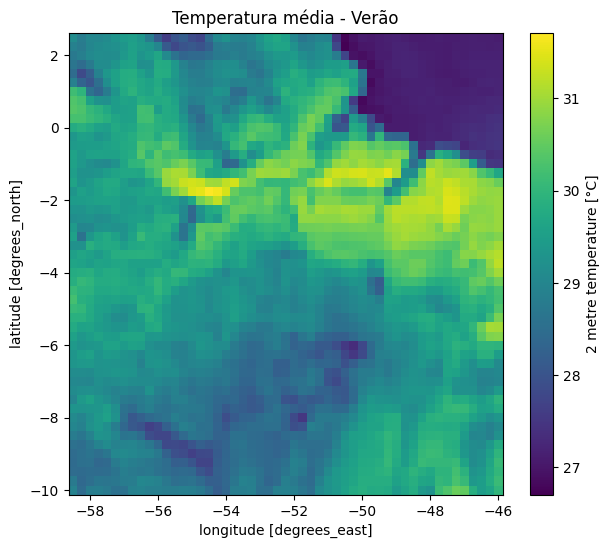

In [36]:
temp_media.sel(
    estacao="Verao"
).plot(
    figsize=(7,6)
)

plt.title("Temperatura média - Verão")
plt.show()

In [37]:
dados = {

"Temperatura":temp_media,

"Precipitacao":prec_media,

"Vento":vento_media,

"Umidade":umidade_media

}

In [38]:
!mkdir -p dados/shapefiles

!wget -O dados/shapefiles/BR_UF_2022.zip \
https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/UFs/BR/BR_UF_2022.zip

!unzip -o dados/shapefiles/BR_UF_2022.zip -d dados/shapefiles/

--2026-07-07 00:31:44--  https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/UFs/BR/BR_UF_2022.zip
Resolving geoftp.ibge.gov.br (geoftp.ibge.gov.br)... 191.233.136.86
Connecting to geoftp.ibge.gov.br (geoftp.ibge.gov.br)|191.233.136.86|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-07-07 00:31:45 ERROR 404: Not Found.

Archive:  dados/shapefiles/BR_UF_2022.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of dados/shapefiles/BR_UF_2022.zip or
        dados/shapefiles/BR_UF_2022.zip.zip, and cannot find dados/shapefiles/BR_UF_2022.zip.ZIP, period.


In [39]:
import os

for raiz, dirs, arquivos in os.walk("dados/shapefiles"):
    for arquivo in arquivos:
        print(os.path.join(raiz, arquivo))

dados/shapefiles/BR_UF_2022.zip


In [40]:
!pip install -q geobr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 114.4 MB/s eta 0:00:00


In [41]:
import geobr

estados = geobr.read_state(year=2024)

estados.head()

states_2024_simplified.parquet: 100%|██████████| 1.79M/1.79M [00:00<00:00, 36.6MB/s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,code_state,name_state,abbrev_state,code_region,name_region,year,geometry
0,11.0,Rondônia,RO,1.0,Norte,2024.0,"POLYGON ((-60.37348 -13.32444, -60.36609 -13.3..."
1,12.0,Acre,AC,1.0,Norte,2024.0,"POLYGON ((-68.39021 -11.04496, -68.39603 -11.0..."
2,13.0,Amazonas,AM,1.0,Norte,2024.0,"POLYGON ((-67.51732 -9.56071, -68.64719 -9.049..."
3,14.0,Roraima,RR,1.0,Norte,2024.0,"POLYGON ((-61.54468 -1.52563, -61.55745 -1.503..."
4,15.0,Pará,PA,1.0,Norte,2024.0,"MULTIPOLYGON (((-51.41904 -9.7652, -52.00032 -..."


<Axes: >

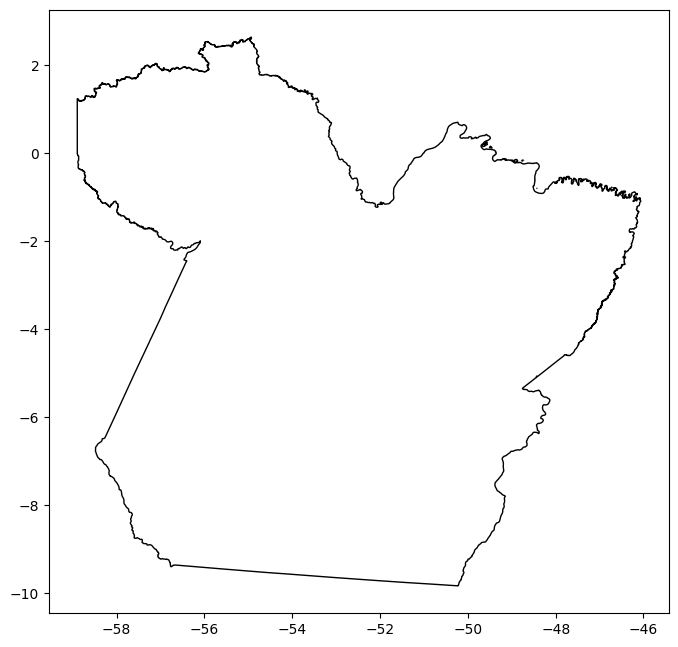

In [42]:
para = estados[estados.abbrev_state=="PA"]

para.plot(figsize=(8,8), edgecolor="black", facecolor="none")

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import geopandas as gpd
import geobr

# Estado do Pará
para = geobr.read_state(year=2020)

para = para[para.abbrev_state == "PA"]

# Municípios do Pará
municipios = geobr.read_municipality(code_muni="PA", year=2024)

states_2020_simplified.parquet: 100%|██████████| 1.72M/1.72M [00:00<00:00, 48.6MB/s]
municipalities_2024_simplified.parquet: 100%|██████████| 20.8M/20.8M [00:00<00:00, 171MB/s]


In [44]:
municipios_produtores = [

    "Igarapé-Miri",
    "Cametá",
    "Abaetetuba",
    "Moju",
    "Barcarena",
    "Mocajuba"

]

produtores = municipios[
    municipios.name_muni.isin(municipios_produtores)
]

In [45]:
def plotar_mapa(
    dado,
    estacao,
    titulo,
    unidade,
    pasta,
    cmap="viridis"
):

    fig = plt.figure(figsize=(10,10))

    ax = plt.axes(
        projection=ccrs.PlateCarree()
    )

    ax.set_extent(
        [LON_MIN,
         LON_MAX,
         LAT_MIN,
         LAT_MAX]
    )

    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.RIVERS, alpha=0.4)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        color="gray"
    )

    gl.top_labels=False
    gl.right_labels=False

    campo = dado.sel(estacao=estacao)

    níveis = 20

    contorno = ax.contourf(

        campo.longitude,

        campo.latitude,

        campo.values,

        levels=níveis,

        cmap=cmap,

        transform=ccrs.PlateCarree()

    )

    para.boundary.plot(

        ax=ax,

        linewidth=2,

        edgecolor="black"

    )

    produtores.boundary.plot(

        ax=ax,

        linewidth=1.6,

        edgecolor="red"

    )

    plt.colorbar(
        contorno,
        ax=ax,
        shrink=0.75,
        label=unidade
    )

    plt.title(
        f"{titulo} - {estacao}",
        fontsize=15,
        weight="bold"
    )

    plt.savefig(

        f"{pasta}/{titulo}_{estacao}.png",

        dpi=300,

        bbox_inches="tight"

    )

    plt.show()

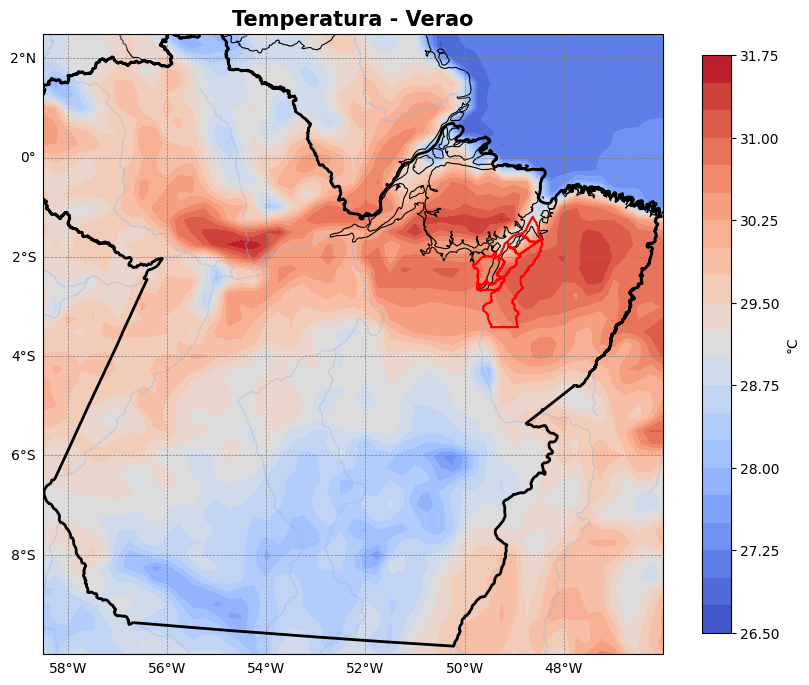

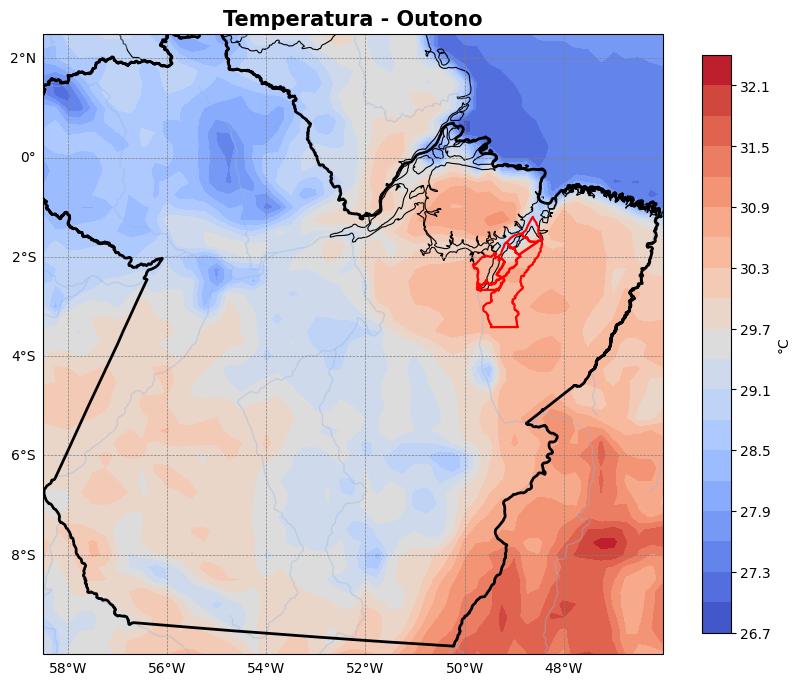

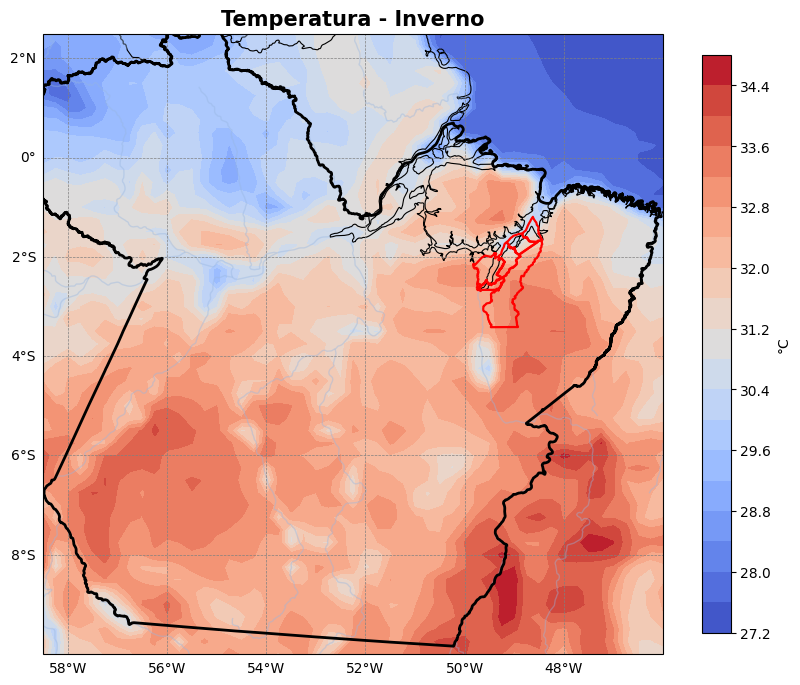

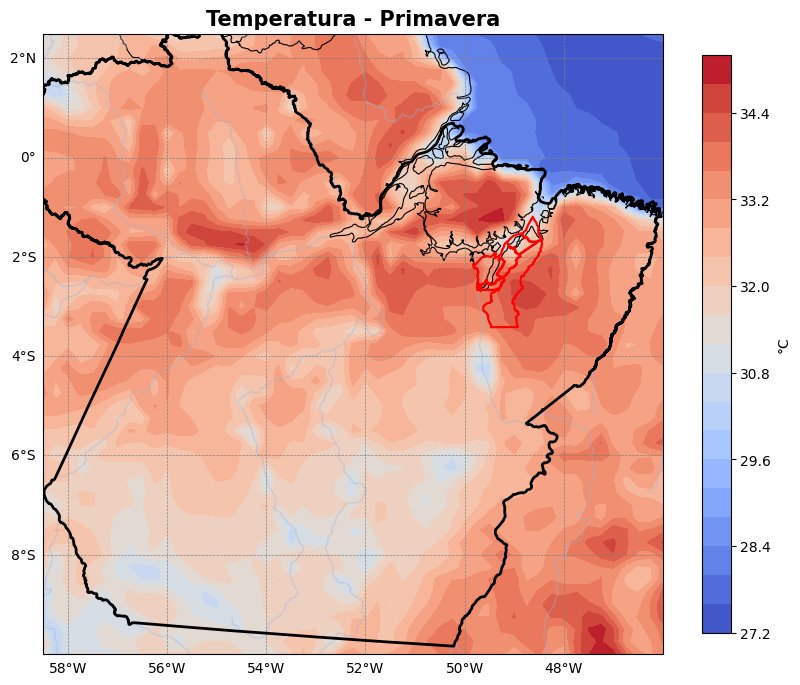

In [46]:
for est in ["Verao","Outono","Inverno","Primavera"]:

    plotar_mapa(

        temp_media,

        est,

        "Temperatura",

        "°C",

        "resultados/temperatura",

        cmap="coolwarm"

    )

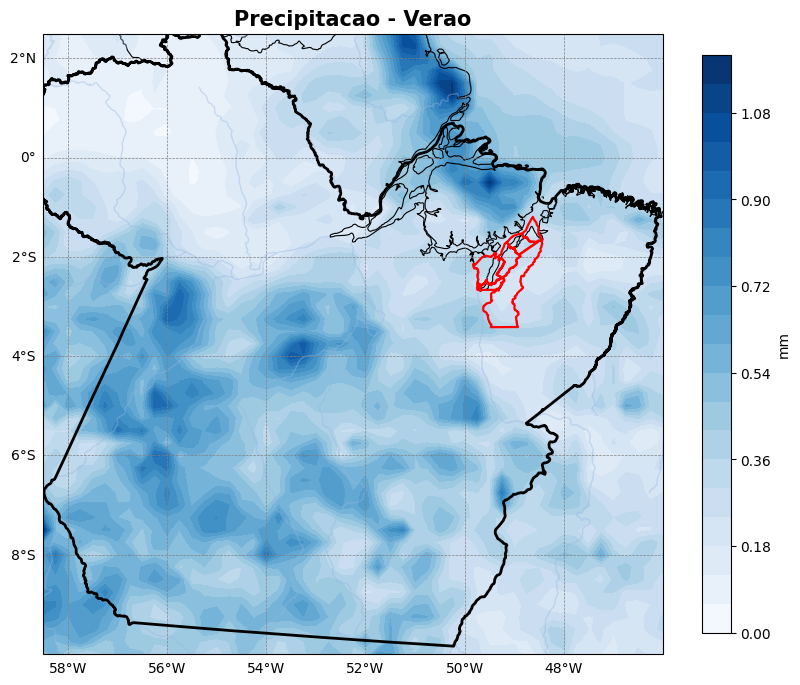

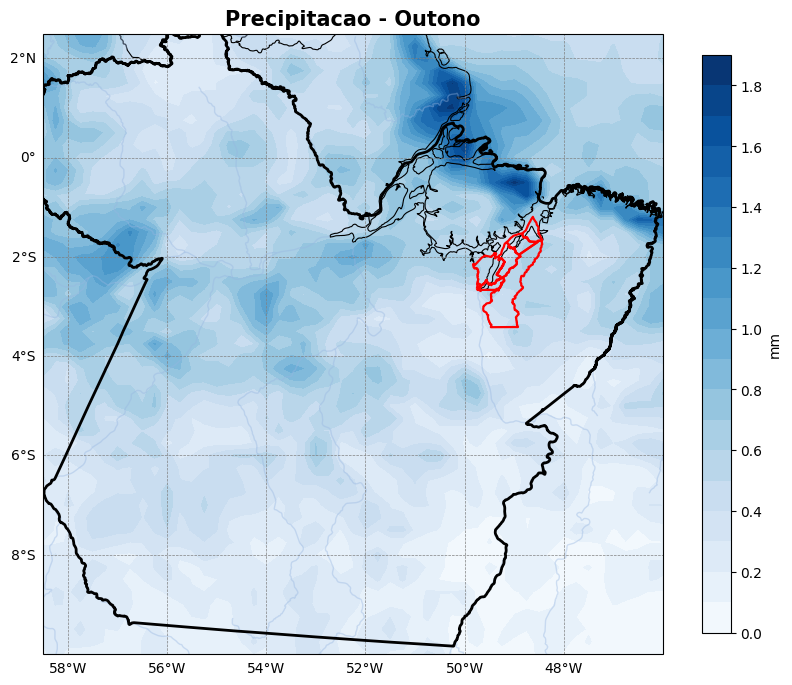

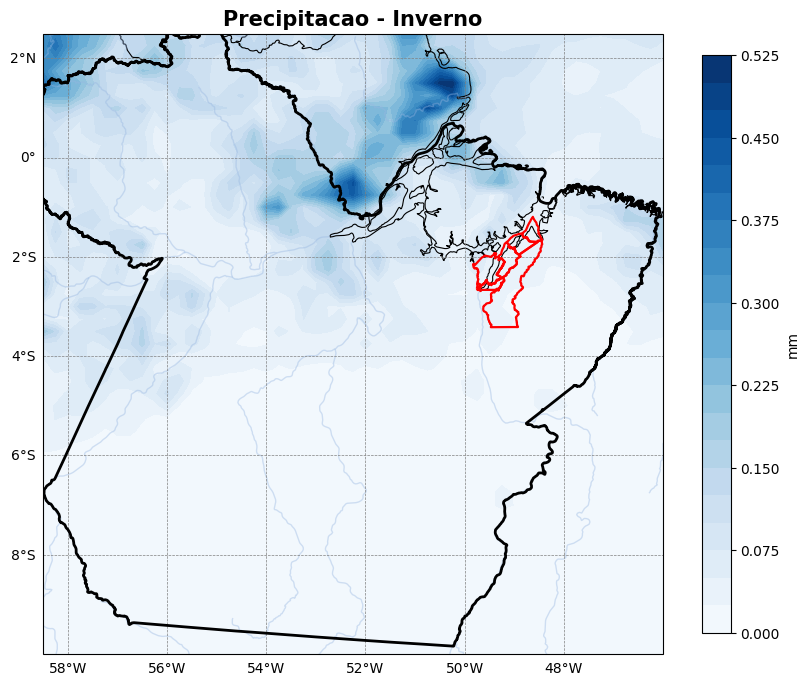

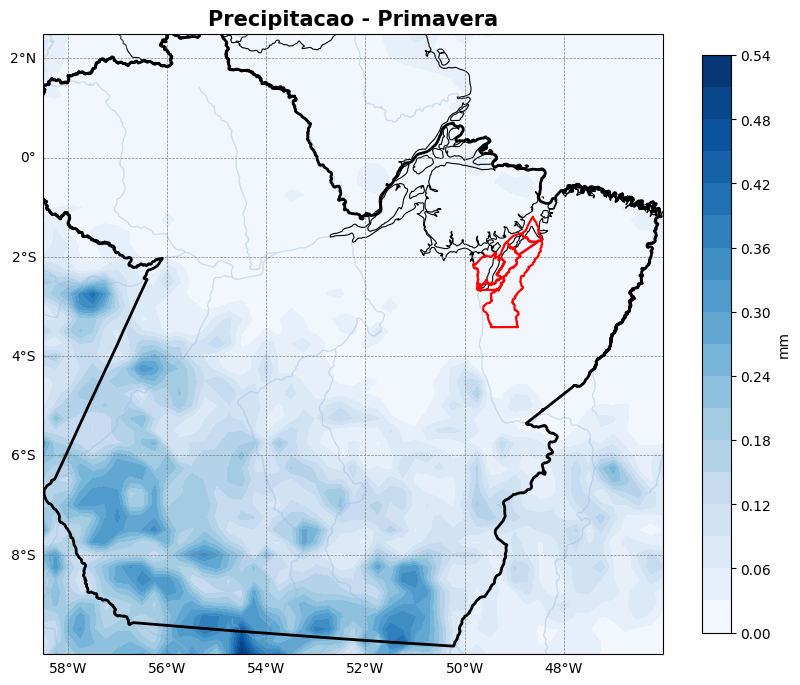

In [47]:
for est in ["Verao","Outono","Inverno","Primavera"]:

    plotar_mapa(

        prec_media,

        est,

        "Precipitacao",

        "mm",

        "resultados/precipitacao",

        cmap="Blues"

    )

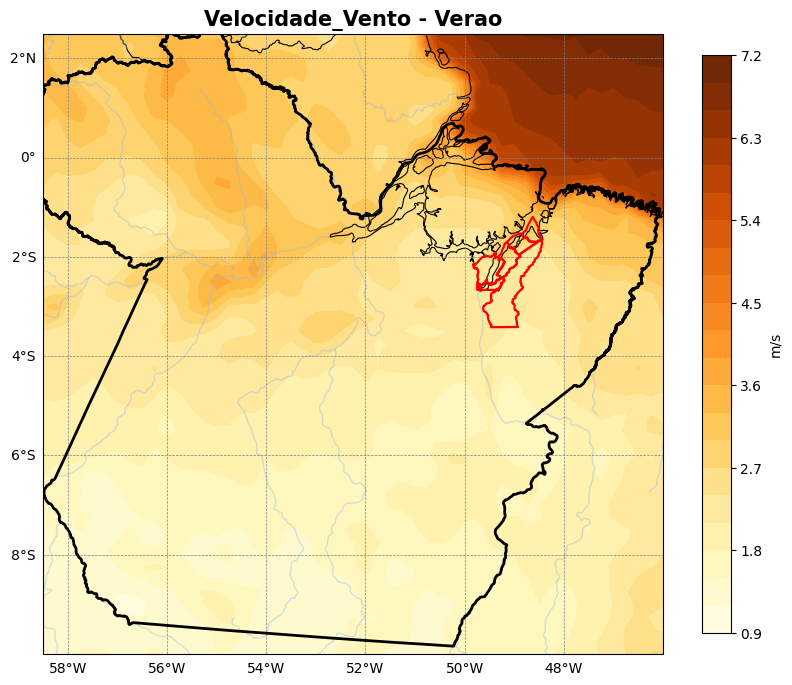

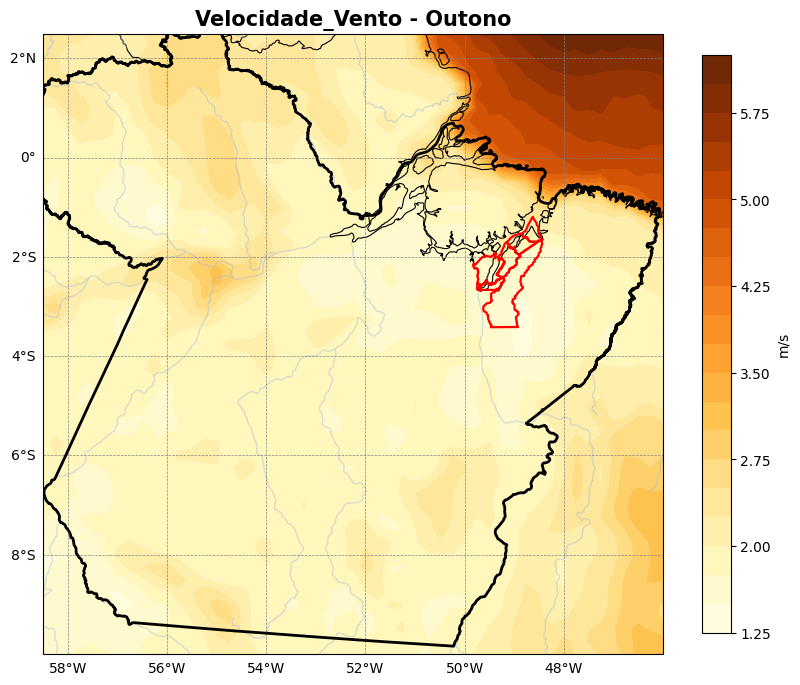

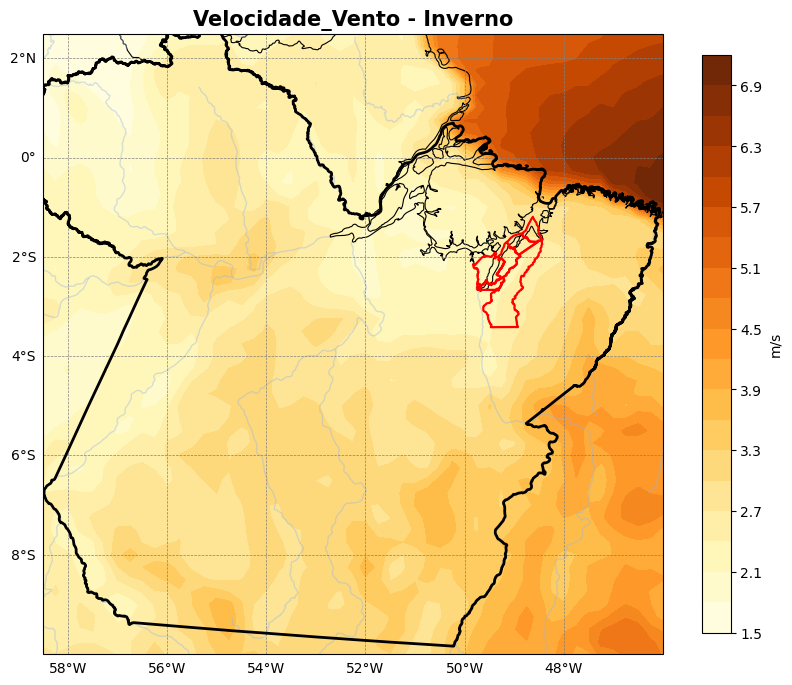

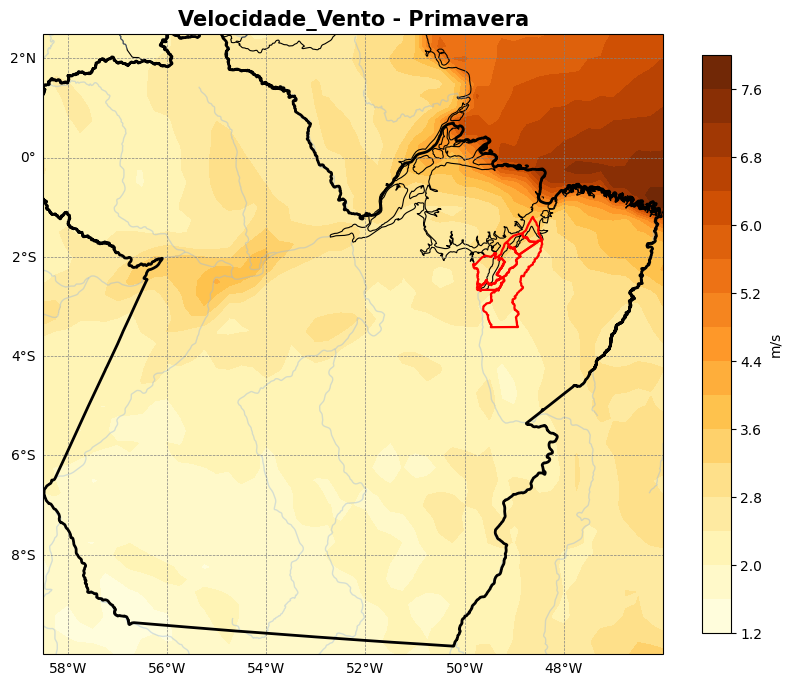

In [48]:
for est in ["Verao","Outono","Inverno","Primavera"]:

    plotar_mapa(

        vento_media,

        est,

        "Velocidade_Vento",

        "m/s",

        "resultados/vento",

        cmap="YlOrBr"

    )

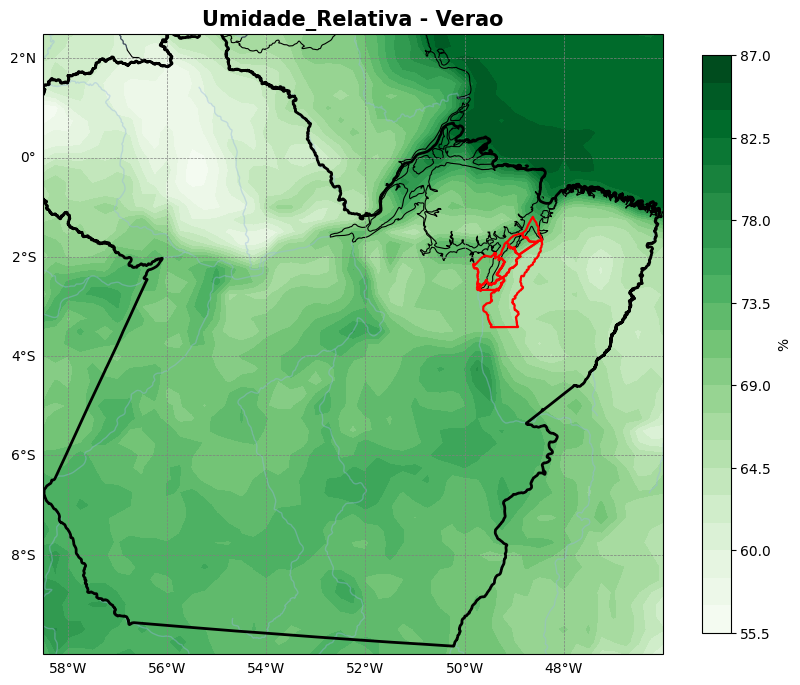

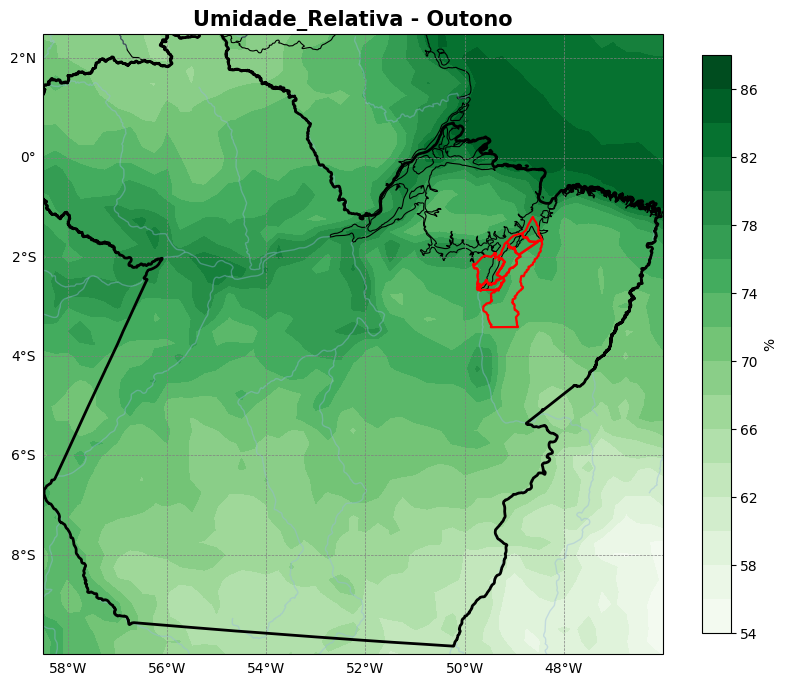

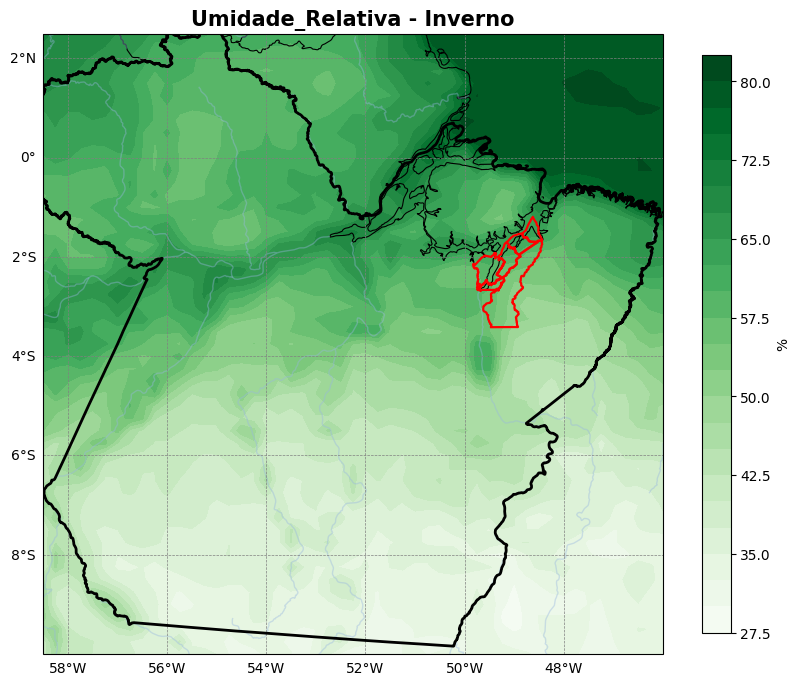

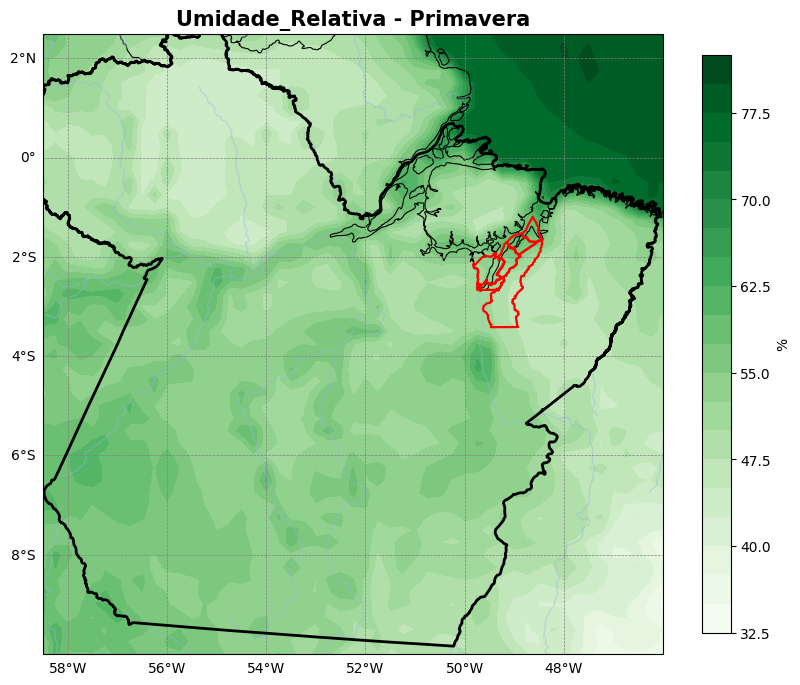

In [49]:
for est in ["Verao","Outono","Inverno","Primavera"]:

    plotar_mapa(

        umidade_media,

        est,

        "Umidade_Relativa",

        "%",

        "resultados/umidade",

        cmap="Greens"

    )

In [50]:
!pip install -q rioxarray matplotlib-scalebar adjustText

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.3 MB/s eta 0:00:00


In [51]:
import rioxarray
from adjustText import adjust_text
from matplotlib_scalebar.scalebar import ScaleBar

In [56]:
# Define o sistema de referência do DataArray
temp_media = temp_media.rio.write_crs("EPSG:4326")
prec_media = prec_media.rio.write_crs("EPSG:4326")
vento_media = vento_media.rio.write_crs("EPSG:4326")
umidade_media = umidade_media.rio.write_crs("EPSG:4326")

# Recorte usando a geometria do Pará
temp_media = temp_media.rio.clip(
    para.geometry.to_list(),
    para.crs,
    drop=True
)

prec_media = prec_media.rio.clip(
    para.geometry.to_list(),
    para.crs,
    drop=True
)

vento_media = vento_media.rio.clip(
    para.geometry.to_list(),
    para.crs,
    drop=True
)

umidade_media = umidade_media.rio.clip(
    para.geometry.to_list(),
    para.crs,
    drop=True
)

In [57]:
ax.set_extent(

[-50.7,
 -47.6,

 -3.4,
 -0.6]

)

NameError: name 'ax' is not defined